In [1]:
import os

# Define the root directory path
root_dir = "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/"

# Check if the path exists before running
if os.path.exists(root_dir):
    print(f"Scanning subdirectories in: {root_dir}\n" + "-"*50)
    
    for root, dirs, files in os.walk(root_dir):
        for directory in dirs:
            print(os.path.join(root, directory))
else:
    print(f"Error: The directory {root_dir} does not exist or is not accessible.")

Scanning subdirectories in: /nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/
--------------------------------------------------
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/110
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/115
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/117
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/119
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/121
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/123
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/126
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/129
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/140
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/150
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/160
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/17
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/170
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/180
/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/21
/nfs/chess/id4

In [72]:


import os
import fabio
import numpy as np
import sys

# Define the root directory path
root_dir = "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/"
direcs = []
# Check if the path exists before running
if os.path.exists(root_dir):
    print(f"Scanning subdirectories in: {root_dir}\n" + "-"*50)
    
    for root, dirs, files in os.walk(root_dir):
        index = 0
        for directory in dirs:
            if (index == 0):
                direcs.append(os.path.join(root, directory))
            index += 1

i =0
while i < len(direcs):
    if (len(direcs[i]) < 60):
        direcs.pop(i)
        i -= 1
    i += 1
# Simulation of your loop
print(direcs)
all_image_stats = []

for path in direcs:
    input_folder = path
    print(path)
    all_files = os.listdir(input_folder)
    cbf_files = sorted([f for f in all_files if f.endswith(".cbf")])[:10]
    print(f"Found {len([f for f in all_files if f.endswith('.cbf')])} CBF files, processing first {len(cbf_files)}")

    
    print(f"Processing {len(cbf_files)} CBF files...")
    
    sum_image = None
    successful_files = 0
    failed_files = []
    
    for i, file in enumerate(cbf_files):
        try:
            file_path = os.path.join(input_folder, file)
            print(file_path)
            if (i + 1) % 5 == 0:
                print(f"Processed {i + 1}/{len(cbf_files)} files ({successful_files} successful)")

            obj = fabio.open(file_path)
            file_path = file_path.split("/")
            file_path = file_path[-3] + file_path[-1]
            obj.write("files/"+file_path)
        except Exception as e:
            print(f"Error with {file}: {e}")
            failed_files.append(file)
        

Scanning subdirectories in: /nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/
--------------------------------------------------
['/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/110/Ta2NiSeS70_036', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/115/Ta2NiSeS70_039', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/117/Ta2NiSeS70_042', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/119/Ta2NiSeS70_045', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/121/Ta2NiSeS70_048', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/123/Ta2NiSeS70_051', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/126/Ta2NiSeS70_054', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/129/Ta2NiSeS70_057', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/140/Ta2NiSeS70_060', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/150/Ta2NiSeS70_063', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/160/Ta2NiSeS70_066', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/T

In [98]:
import fabio
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
import time

start = time.time()
# -------------------------------
# Paths
# -------------------------------
input_folder = "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/110/Ta2NiSeS70_036"
output_folder = "/nfs/chess/user/aa2994/example"

# Validate input folder exists
if not os.path.exists(input_folder):
    print(f"ERROR: Input folder does not exist: {input_folder}")
    sys.exit(1)

# Create output folder
try:
    os.makedirs(output_folder, exist_ok=True)
    print(f"Output folder ready: {output_folder}")
except Exception as e:
    print(f"ERROR: Cannot create output folder: {e}")
    sys.exit(1)

# -------------------------------
# Load and sum files (optimized)
# -------------------------------
try:
    all_files = os.listdir(input_folder)
    cbf_files = sorted([f for f in all_files if f.endswith(".cbf")])[:10]
    print(f"Found {len([f for f in all_files if f.endswith('.cbf')])} CBF files, processing first {len(cbf_files)}")
except Exception as e:
    print(f"ERROR: Cannot read input folder: {e}")
    sys.exit(1)

if len(cbf_files) == 0:
    print("ERROR: No CBF files found!")
    print(f"Files in directory: {all_files[:2]}")  # Show first 10 files for debugging
    sys.exit(1)

print(f"Processing {len(cbf_files)} CBF files...")

sum_image = None
successful_files = 0
failed_files = []

for i, file in enumerate(cbf_files):
    try:
        file_path = os.path.join(input_folder, file)
        if not os.path.exists(file_path):
            print(f"Warning: File does not exist: {file}")
            failed_files.append(file)
            continue
            
        data = fabio.open(file_path).data
        
        if sum_image is None:
            sum_image = data.astype(np.float32)
        else:
            sum_image += data
            
        successful_files += 1
        
        if (i + 1) % 5 == 0:
            print(f"Processed {i + 1}/{len(cbf_files)} files ({successful_files} successful)")
            
    except Exception as e:
        print(f"Error with {file}: {e}")
        failed_files.append(file)

if sum_image is None:
    print("ERROR: No valid data loaded!")
    print(f"Failed files: {failed_files}")
    sys.exit(1)

print(f"Sum complete: {sum_image.shape}, range [{sum_image.min():.1f}, {sum_image.max():.1f}]")
print(f"Successfully processed {successful_files}/{len(cbf_files)} files")

if failed_files:
    print(f"Failed files ({len(failed_files)}): {failed_files}")

# Remove negatives
negative_count = np.sum(sum_image < 0)
if negative_count > 0:
    print(f"Removing {negative_count:,} negative pixels")
    sum_image = np.maximum(sum_image, 0)

# -------------------------------
# Log method only
# -------------------------------
print("Applying logarithmic transformation...")
log_img = np.log1p(sum_image)  # log(1 + x) to handle zeros
#log_img = 5**log_img
#vmin, vmax = np.percentile(log_img, [5, 99.5]) #seems arbitrary??
vmin, vmax = np.percentile(log_img, [1, 99.9])
log_processed = np.clip((log_img - vmin) / (vmax - vmin), 0, 1)

print(f"Log transform: original range [{sum_image.min():.1f}, {sum_image.max():.1f}] "
      f"→ log range [{log_img.min():.3f}, {log_img.max():.3f}] "
      f"→ normalized [{log_processed.min():.3f}, {log_processed.max():.3f}]")

# -------------------------------
# Visualization
# -------------------------------
print("Creating visualization...")
try:
    plt.figure(figsize=(10, 8))
    im = plt.imshow(log_processed, cmap='gist_ncar', origin='lower')
    plt.title(f'Log Transform Method\n{successful_files} CBF files summed', fontsize=14)
    plt.colorbar(im, label='Normalized Log Intensity')
    plt.xlabel('Detector X (pixels)')
    plt.ylabel('Detector Y (pixels)')
    
    # Add some statistics to the plot
    plt.figtext(0.02, 0.02, 
                f'Original range: [{sum_image.min():.0f}, {sum_image.max():.0f}]\n'
                f'Dynamic range: {np.log10(sum_image.max() / np.maximum(sum_image[sum_image > 0].min(), 1)):.1f} decades',
                fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    output_plot = os.path.join(output_folder, "log_method2.png")
    plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Plot saved to: {output_plot}")
    
    # Show plot (comment out if running on headless system)
    # plt.show()
    plt.close()
    
except Exception as e:
    print(f"Warning: Could not create plot: {e}")

# Save raw data
try:
    raw_output = os.path.join(output_folder, "summed_raw.npy")
    np.save(raw_output, sum_image)
    print(f"Raw data saved to: {raw_output}")
except Exception as e:
    print(f"Warning: Could not save raw data: {e}")

# -------------------------------
# Calculate all statistics
# -------------------------------
print("Calculating comprehensive statistics...")

# Basic stats
shape = sum_image.shape
total_pixels = sum_image.size
min_val = sum_image.min()
max_val = sum_image.max()
mean_val = sum_image.mean()
median_val = np.median(sum_image)
std_val = sum_image.std()

# Data distribution
nonzero_count = np.count_nonzero(sum_image)
zero_count = sum_image.size - nonzero_count
nonzero_percent = 100 * nonzero_count / sum_image.size
zero_percent = 100 * zero_count / sum_image.size
unique_values = len(np.unique(sum_image))

# Percentiles
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5]
perc_values = np.percentile(sum_image, percentiles)

# Dynamic range and intensity analysis
dynamic_range = max_val / np.maximum(min_val, 1)
positive_data = sum_image[sum_image > 0]
log_dynamic_range = np.log10(max_val / np.maximum(positive_data.min(), 1)) if len(positive_data) > 0 else 0
snr = mean_val / np.maximum(std_val, 1e-10)
coeff_variation = std_val / np.maximum(mean_val, 1e-10)

# Hot pixels and outliers
threshold_99_9 = np.percentile(sum_image, 99.9)
hot_pixels = np.sum(sum_image > threshold_99_9)
hot_pixels_percent = 100 * hot_pixels / sum_image.size
outliers_3sigma = np.sum(sum_image > mean_val + 3 * std_val)

# Memory usage
memory_mb = sum_image.nbytes / (1024**2)

# Non-zero data statistics
if len(positive_data) > 0:
    nonzero_min = positive_data.min()
    nonzero_mean = positive_data.mean()
    nonzero_std = positive_data.std()
else:
    nonzero_min = nonzero_mean = nonzero_std = 0

# Image quality metrics
total_intensity = sum_image.sum()
avg_intensity_per_file = total_intensity / successful_files

# Calculate entropy more safely
sum_image_safe = sum_image + 1e-10  # Avoid log(0)
sum_image_norm = sum_image_safe / sum_image_safe.sum()  # Normalize for proper entropy
entropy = -np.sum(sum_image_norm * np.log(sum_image_norm))

# Log processed statistics
log_min = log_processed.min()
log_max = log_processed.max()
log_mean = log_processed.mean()
log_std = log_processed.std()

print(f"Statistics calculated - Dynamic range: {log_dynamic_range:.2f} decades, "
      f"SNR: {snr:.1f}, Non-zero pixels: {nonzero_percent:.1f}%")

# -------------------------------
# Write comprehensive statistics to text file
# -------------------------------
stats_file = os.path.join(output_folder, "image_statistics_report2.txt")

try:
    with open(stats_file, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("IMAGE STATISTICS REPORT - DETAILED ANALYSIS\n")
        f.write("=" * 80 + "\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Input folder: {input_folder}\n")
        f.write(f"Files processed successfully: {successful_files}/{len(cbf_files)}\n")
        if failed_files:
            f.write(f"Failed files: {len(failed_files)}\n")
        f.write("=" * 80 + "\n\n")
        
        # BASIC IMAGE PROPERTIES
        f.write("1. BASIC IMAGE PROPERTIES\n")
        f.write("-" * 40 + "\n")
        f.write(f"Shape: {shape}\n")
        f.write("  → Image dimensions in pixels (height × width)\n\n")
        
        f.write(f"Total pixels: {total_pixels:,}\n")
        f.write("  → Total number of detector pixels\n\n")
        
        f.write(f"Data type: {sum_image.dtype}\n")
        f.write("  → Memory format used to store pixel values\n\n")
        
        f.write(f"Memory usage: {memory_mb:.1f} MB\n")
        f.write("  → RAM required to store this image\n\n")
        
        # INTENSITY STATISTICS
        f.write("2. INTENSITY STATISTICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Minimum value: {min_val:.3f}\n")
        f.write("  → Lowest intensity recorded (background level after negative removal)\n\n")
        
        f.write(f"Maximum value: {max_val:.3f}\n")
        f.write("  → Highest intensity recorded (brightest diffraction spot)\n\n")
        
        f.write(f"Mean value: {mean_val:.3f}\n")
        f.write("  → Average intensity across all pixels\n\n")
        
        f.write(f"Median value: {median_val:.3f}\n")
        f.write("  → Middle value when all pixels are sorted by intensity\n")
        f.write("  → Less affected by extreme outliers than mean\n\n")
        
        f.write(f"Standard deviation: {std_val:.3f}\n")
        f.write("  → Measure of intensity variation across the image\n")
        f.write("  → High values indicate more contrast/dynamic range\n\n")
        
        # DATA DISTRIBUTION
        f.write("3. DATA DISTRIBUTION ANALYSIS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Non-zero pixels: {nonzero_count:,} ({nonzero_percent:.1f}%)\n")
        f.write("  → Pixels with actual signal above zero\n")
        f.write("  → Higher percentages indicate more diffraction coverage\n\n")
        
        f.write(f"Zero pixels: {zero_count:,} ({zero_percent:.1f}%)\n")
        f.write("  → Background/empty regions of detector\n\n")
        
        f.write(f"Unique intensity values: {unique_values:,}\n")
        f.write("  → Number of distinct intensity levels in the image\n")
        f.write("  → Higher values indicate better intensity resolution\n\n")
        
        # PERCENTILE ANALYSIS
        f.write("4. PERCENTILE ANALYSIS\n")
        f.write("-" * 40 + "\n")
        f.write("Intensity distribution breakdown:\n")
        for p, v in zip(percentiles, perc_values):
            f.write(f"  {p:3f}th percentile: {v:.3f}\n")
        f.write("\nExplanation:\n")
        f.write("  → Shows how intensities are distributed across the image\n")
        f.write("  → 50th percentile = median\n")
        f.write("  → 99th percentile shows where the brightest 1% of pixels start\n")
        f.write("  → Large gaps between percentiles indicate intensity clustering\n\n")
        
        # DYNAMIC RANGE
        f.write("5. DYNAMIC RANGE ANALYSIS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Linear dynamic range: {dynamic_range:.1f}\n")
        f.write("  → Ratio of brightest to dimmest pixel (max/min)\n")
        f.write("  → Higher values mean more contrast in the image\n\n")
        
        f.write(f"Logarithmic dynamic range: {log_dynamic_range:.2f} decades\n")
        f.write("  → Dynamic range expressed in orders of magnitude\n")
        f.write("  → >3 decades indicates high dynamic range requiring log scaling\n")
        f.write("  → <1 decade suggests low contrast image\n\n")
        
        # SIGNAL QUALITY
        f.write("6. SIGNAL QUALITY METRICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Signal-to-noise ratio: {snr:.2f}\n")
        f.write("  → Mean intensity divided by standard deviation\n")
        f.write("  → Higher values indicate cleaner, less noisy data\n")
        f.write("  → Values >10 are generally considered good\n\n")
        
        f.write(f"Coefficient of variation: {coeff_variation:.3f}\n")
        f.write("  → Normalized measure of intensity variation (std/mean)\n")
        f.write("  → Lower values indicate more uniform intensity distribution\n")
        f.write("  → Higher values indicate more contrast\n\n")
        
        # OUTLIER DETECTION
        f.write("7. OUTLIER AND HOT PIXEL ANALYSIS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Hot pixels (>99.9th percentile): {hot_pixels:,} ({hot_pixels_percent:.3f}%)\n")
        f.write("  → Extremely bright pixels that may be detector artifacts\n")
        f.write("  → Values >0.1% may indicate detector issues\n\n")
        
        f.write(f"Extreme outliers (>mean+3σ): {outliers_3sigma:,}\n")
        f.write("  → Pixels more than 3 standard deviations above mean\n")
        f.write("  → Statistical outliers that may need special handling\n\n")
        
        # NON-ZERO DATA ANALYSIS
        f.write("8. ACTIVE SIGNAL ANALYSIS (Positive pixels only)\n")
        f.write("-" * 40 + "\n")
        if len(positive_data) > 0:
            f.write(f"Minimum (positive): {nonzero_min:.3f}\n")
            f.write("  → Weakest detectable signal above background\n\n")
            
            f.write(f"Mean (positive): {nonzero_mean:.3f}\n")
            f.write("  → Average intensity of actual diffraction signals\n\n")
            
            f.write(f"Standard deviation (positive): {nonzero_std:.3f}\n")
            f.write("  → Variation within the active diffraction regions\n\n")
        else:
            f.write("No positive pixels found in the image.\n\n")
        
        # EXPERIMENT SUMMARY
        f.write("9. EXPERIMENT SUMMARY\n")
        f.write("-" * 40 + "\n")
        f.write(f"Total integrated intensity: {total_intensity:.0f}\n")
        f.write("  → Sum of all pixel intensities (total diffracted signal)\n\n")
        
        f.write(f"Average intensity per file: {avg_intensity_per_file:.0f}\n")
        f.write("  → Mean contribution from each input image\n\n")
        
        f.write(f"Information entropy: {entropy:.2e}\n")
        f.write("  → Measure of information content in the image\n")
        f.write("  → Higher values indicate more complex intensity patterns\n\n")
        
        # LOG PROCESSING RESULTS
        f.write("10. LOG-PROCESSED IMAGE STATISTICS\n")
        f.write("-" * 40 + "\n")
        f.write(f"Processed range: {log_min:.3f} to {log_max:.3f}\n")
        f.write("  → Intensity range after logarithmic transformation and normalization\n\n")
        
        f.write(f"Processed mean: {log_mean:.3f}\n")
        f.write("  → Average intensity in the display-optimized image\n\n")
        
        f.write(f"Processed std: {log_std:.3f}\n")
        f.write("  → Contrast level in the final processed image\n\n")
        
        # INTERPRETATION GUIDE
        f.write("11. INTERPRETATION GUIDE\n")
        f.write("-" * 40 + "\n")
        f.write("GOOD DIFFRACTION DATA INDICATORS:\n")
        f.write("• High non-zero pixel percentage (>10%)\n")
        f.write("• Log dynamic range > 2 decades\n")
        f.write("• Signal-to-noise ratio > 5\n")
        f.write("• Low hot pixel percentage (<0.01%)\n\n")
        
        f.write("POTENTIAL ISSUES TO CHECK:\n")
        f.write("• Very low non-zero percentage → weak diffraction\n")
        f.write("• Many hot pixels → detector problems\n")
        f.write("• Very high/low SNR → check exposure settings\n")
        f.write("• Low dynamic range → check sample/beam alignment\n\n")
        
        f.write("DATA PROCESSING RECOMMENDATIONS:\n")
        f.write(f"• Dynamic range: {log_dynamic_range:.1f} decades → ")
        if log_dynamic_range > 3:
            f.write("Use logarithmic scaling for visualization\n")
        elif log_dynamic_range > 1:
            f.write("Square root scaling may be sufficient\n")
        else:
            f.write("Linear scaling should work fine\n")
        
        f.write(f"• Hot pixels: {hot_pixels_percent:.3f}% → ")
        if hot_pixels_percent > 0.01:
            f.write("Consider hot pixel correction\n")
        else:
            f.write("Hot pixel levels are acceptable\n")
        
        # FILE PROCESSING SUMMARY
        if failed_files:
            f.write(f"\n12. PROCESSING ISSUES\n")
            f.write("-" * 40 + "\n")
            f.write(f"Failed to process {len(failed_files)} files:\n")
            for failed_file in failed_files:
                f.write(f"  • {failed_file}\n")
            f.write("\nRecommendation: Check file integrity and format\n")
        
        f.write("\n" + "=" * 80 + "\n")
        f.write("END OF REPORT\n")
        f.write("=" * 80 + "\n")
    
    print(f"✓ Detailed statistics saved to: {stats_file}")
    
except Exception as e:
    print(f"ERROR: Could not write statistics file: {e}")

print("✓ Log processing complete!")

# Print summary to console
print(f"\n{'='*60}")
print("PROCESSING SUMMARY")
print(f"{'='*60}")
print(f"Files processed: {successful_files}/{len(cbf_files)}")
print(f"Image shape: {shape}")
print(f"Intensity range: [{min_val:.0f}, {max_val:.0f}]")
print(f"Dynamic range: {log_dynamic_range:.1f} decades")
print(f"Non-zero pixels: {nonzero_percent:.1f}%")
print(f"Signal-to-noise: {snr:.1f}")
print(f"Output files saved to: {output_folder}")
print(f"{'='*60}")
end = time.time()
print(end-start)

Output folder ready: /nfs/chess/user/aa2994/example
Found 3651 CBF files, processing first 10
Processing 10 CBF files...
Processed 5/10 files (5 successful)
Processed 10/10 files (10 successful)
Sum complete: (2527, 2463), range [-20.0, 1219942.0]
Successfully processed 10/10 files
Removing 526,973 negative pixels
Applying logarithmic transformation...
Log transform: original range [0.0, 1219942.0] → log range [0.000, 14.014] → normalized [0.000, 1.000]
Creating visualization...
Plot saved to: /nfs/chess/user/aa2994/example/log_method2.png
Raw data saved to: /nfs/chess/user/aa2994/example/summed_raw.npy
Calculating comprehensive statistics...
Statistics calculated - Dynamic range: 6.09 decades, SNR: 0.0, Non-zero pixels: 87.8%
✓ Detailed statistics saved to: /nfs/chess/user/aa2994/example/image_statistics_report2.txt
✓ Log processing complete!

PROCESSING SUMMARY
Files processed: 10/10
Image shape: (2527, 2463)
Intensity range: [0, 1219942]
Dynamic range: 6.1 decades
Non-zero pixels: 8

In [ ]:
20 = 3.099
200 = 15.8
2000 = 138.3
3651 = 189.02

In [100]:
import fabio
mask = fabio.open('mask.edf')
mask = mask.data
i = 0
while i < len(mask):
    j = 0
    while j < len(mask[i]):
        if (mask[i][j] == 1):
            log_processed[i][j] *= 0
        j += 1
    i += 1


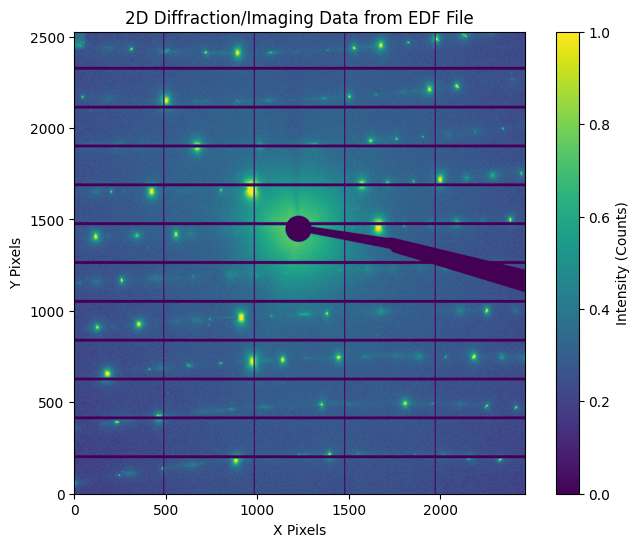

In [101]:
plt.figure(figsize=(8, 6))

# Plot the 2D matrix (use a suitable colormap like 'viridis', 'gray', or 'inferno')
# 'origin=lower' matches standard scientific matrix coordinate mapping
im = plt.imshow(log_processed, cmap='viridis', origin='lower')
# 4. Add visual indicators
plt.colorbar(im, label='Intensity (Counts)')
plt.title('2D Diffraction/Imaging Data from EDF File')
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')

# 5. Display the window
plt.show()


In [ ]:
temp = log_processed

In [ ]:
print(len(temp))
print(len(temp[0]))

i = 1300
while i <= 1600:
    j =  1400
    while j >= 1000:
        temp[i][j] = 0
        j -= 1
    i+= 1

plt.figure(figsize=(8, 6))

# Plot the 2D matrix (use a suitable colormap like 'viridis', 'gray', or 'inferno')
# 'origin=lower' matches standard scientific matrix coordinate mapping
im = plt.imshow(temp, cmap='viridis', origin='lower')
# 4. Add visual indicators
plt.colorbar(im, label='Intensity (Counts)')
plt.title('2D Diffraction/Imaging Data from EDF File')
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')

# 5. Display the window
plt.show()


Plot saved to: /nfs/chess/user/aa2994/example/pic.png


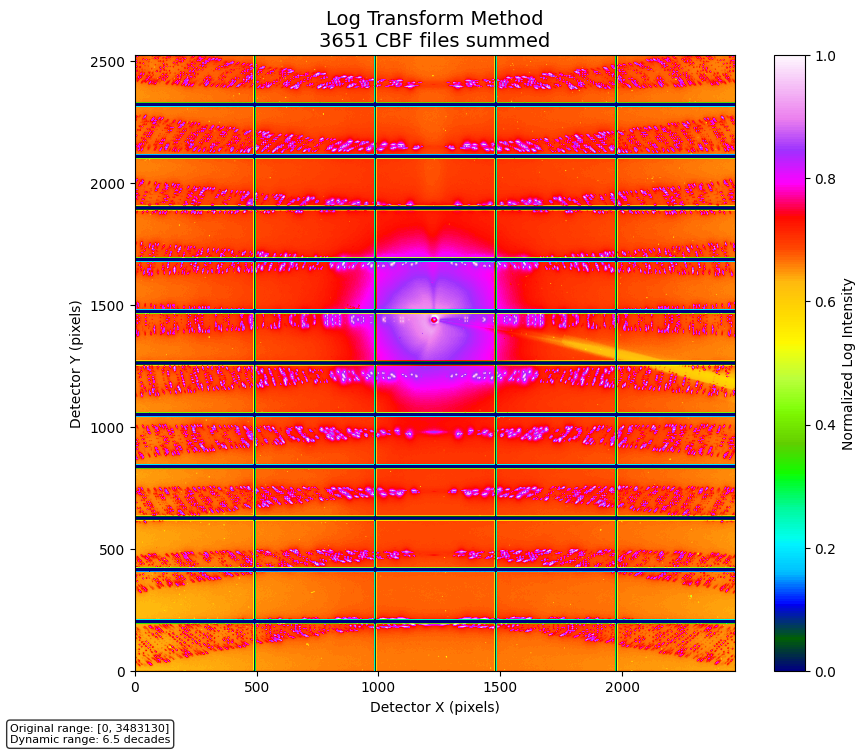

In [7]:
plt.figure(figsize=(10, 8))
im = plt.imshow(log_processed, cmap='gist_ncar', origin='lower')
plt.title(f'Log Transform Method\n{successful_files} CBF files summed', fontsize=14)
plt.colorbar(im, label='Normalized Log Intensity')
plt.xlabel('Detector X (pixels)')
plt.ylabel('Detector Y (pixels)')

# Add some statistics to the plot
plt.figtext(0.02, 0.02, 
            f'Original range: [{sum_image.min():.0f}, {sum_image.max():.0f}]\n'
            f'Dynamic range: {np.log10(sum_image.max() / np.maximum(sum_image[sum_image > 0].min(), 1)):.1f} decades',
            fontsize=8, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

output_plot = os.path.join(output_folder, "pic.png")
plt.savefig(output_plot, dpi=150, bbox_inches='tight', facecolor='white')
print(f"Plot saved to: {output_plot}")

In [29]:
import numpy as np


def extract_image_stats(sum_image, log_processed, successful_files, path):
    """Calculates and returns a dictionary of statistics for a single image."""
    shape = sum_image.shape
    total_pixels = sum_image.size
    min_val = sum_image.min()
    max_val = sum_image.max()
    mean_val = sum_image.mean()
    median_val = np.median(sum_image)
    std_val = sum_image.std()

    # Data distribution
    nonzero_count = np.count_nonzero(sum_image)
    zero_count = sum_image.size - nonzero_count
    nonzero_percent = 100 * nonzero_count / sum_image.size
    zero_percent = 100 * zero_count / sum_image.size
    unique_values = len(np.unique(sum_image))

    # Percentiles
    percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99, 99.5]
    perc_values = np.percentile(sum_image, percentiles)

    # Dynamic range and intensity analysis
    dynamic_range = max_val / np.maximum(min_val, 1)
    positive_data = sum_image[sum_image > 0]
    if len(positive_data) > 0:
        log_dynamic_range = np.log10(
            max_val / np.maximum(positive_data.min(), 1)
        )
    else:
        log_dynamic_range = 0
    snr = mean_val / np.maximum(std_val, 1e-10)
    coeff_variation = std_val / np.maximum(mean_val, 1e-10)

    # Hot pixels and outliers
    threshold_99_9 = np.percentile(sum_image, 99.9)
    hot_pixels = np.sum(sum_image > threshold_99_9)
    hot_pixels_percent = 100 * hot_pixels / sum_image.size
    outliers_3sigma = np.sum(sum_image > mean_val + 3 * std_val)

    # Memory usage
    memory_mb = sum_image.nbytes / (1024**2)

    # Non-zero data statistics
    if len(positive_data) > 0:
        nonzero_min = positive_data.min()
        nonzero_mean = positive_data.mean()
        nonzero_std = positive_data.std()
    else:
        nonzero_min = nonzero_mean = nonzero_std = 0

    # Image quality metrics
    total_intensity = sum_image.sum()
    avg_intensity_per_file = total_intensity / successful_files

    # Calculate entropy more safely
    sum_image_safe = sum_image + 1e-10  # Avoid log(0)
    sum_image_norm = (
        sum_image_safe / sum_image_safe.sum()
    )  # Normalize for proper entropy
    entropy = -np.sum(sum_image_norm * np.log(sum_image_norm))

    # Log processed statistics
    log_min = log_processed.min()
    log_max = log_processed.max()
    log_mean = log_processed.mean()
    log_std = log_processed.std()

    # Pack everything neatly into a dictionary
    stats = {
        "shape": shape,
        "total_pixels": total_pixels,
        "min_val": min_val,
        "max_val": max_val,
        "mean_val": mean_val,
        "median_val": median_val,
        "std_val": std_val,
        "nonzero_count": nonzero_count,
        "zero_count": zero_count,
        "nonzero_percent": nonzero_percent,
        "zero_percent": zero_percent,
        "unique_values": unique_values,
        "percentiles": perc_values,  # Saves as an array of percentiles
        "dynamic_range": dynamic_range,
        "log_dynamic_range": log_dynamic_range,
        "snr": snr,
        "coeff_variation": coeff_variation,
        "hot_pixels": hot_pixels,
        "hot_pixels_percent": hot_pixels_percent,
        "outliers_3sigma": outliers_3sigma,
        "memory_mb": memory_mb,
        "nonzero_min": nonzero_min,
        "nonzero_mean": nonzero_mean,
        "nonzero_std": nonzero_std,
        "total_intensity": total_intensity,
        "avg_intensity_per_file": avg_intensity_per_file,
        "entropy": entropy,
        "log_min": log_min,
        "log_max": log_max,
        "log_mean": log_mean,
        "log_std": log_std,
        "path": path,
    }

    return stats


# --- INITIALIZE THE EMPTY LIST HERE ---
all_image_stats = []

In [51]:
import os
import fabio
import numpy as np
import sys

# Define the root directory path
root_dir = "/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/"
direcs = []
# Check if the path exists before running
if os.path.exists(root_dir):
    print(f"Scanning subdirectories in: {root_dir}\n" + "-"*50)
    
    for root, dirs, files in os.walk(root_dir):
        for directory in dirs:
            direcs.append(os.path.join(root, directory))

i =0
while i < len(direcs):
    if (len(direcs[i]) < 60):
        direcs.pop(i)
        i -= 1
    i += 1
# Simulation of your loop
print(direcs)
all_image_stats = []

for path in direcs:
    input_folder = path
    
    all_files = os.listdir(input_folder)
    cbf_files = sorted([f for f in all_files if f.endswith(".cbf")])[:10]
    print(f"Found {len([f for f in all_files if f.endswith('.cbf')])} CBF files, processing first {len(cbf_files)}")

    
    print(f"Processing {len(cbf_files)} CBF files...")
    
    sum_image = None
    successful_files = 0
    failed_files = []
    
    for i, file in enumerate(cbf_files):
        try:
            file_path = os.path.join(input_folder, file)
            if not os.path.exists(file_path):
                print(f"Warning: File does not exist: {file}")
                failed_files.append(file)
                continue
                
            data = fabio.open(file_path).data
            
            if sum_image is None:
                sum_image = data.astype(np.float32)
            else:
                sum_image += data
                
            successful_files += 1
            
            if (i + 1) % 5 == 0:
                print(f"Processed {i + 1}/{len(cbf_files)} files ({successful_files} successful)")
                
        except Exception as e:
            print(f"Error with {file}: {e}")
            failed_files.append(file)
    
    if sum_image is None:
        print("ERROR: No valid data loaded!")
        print(f"Failed files: {failed_files}")
        sys.exit(1)
    
    print(f"Sum complete: {sum_image.shape}, range [{sum_image.min():.1f}, {sum_image.max():.1f}]")
    print(f"Successfully processed {successful_files}/{len(cbf_files)} files")
    
    if failed_files:
        print(f"Failed files ({len(failed_files)}): {failed_files}")
    
    # Remove negatives
    negative_count = np.sum(sum_image < 0)
    if negative_count > 0:
        print(f"Removing {negative_count:,} negative pixels")
        sum_image = np.maximum(sum_image, 0)
    
    # -------------------------------
    # Log method only
    # -------------------------------
    print("Applying logarithmic transformation...")
    log_img = np.log1p(sum_image)  # log(1 + x) to handle zeros
    #vmin, vmax = np.percentile(log_img, [5, 99.5]) #seems arbitrary??
    vmin, vmax = np.percentile(log_img, [1, 99.9])
    log_processed = np.clip((log_img - vmin) / (vmax - vmin), 0, 1)
    

    # 2. Extract stats for the current image
    current_stats = extract_image_stats(
        sum_image, log_processed, successful_files, path
    )

    # 3. Append to your master list
    all_image_stats.append(current_stats)

print("FINISHED")

Scanning subdirectories in: /nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/
--------------------------------------------------
['/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/110/Ta2NiSeS70_036', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/110/Ta2NiSeS70_037', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/110/Ta2NiSeS70_038', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/115/Ta2NiSeS70_039', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/115/Ta2NiSeS70_040', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/115/Ta2NiSeS70_041', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/117/Ta2NiSeS70_042', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/117/Ta2NiSeS70_043', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/117/Ta2NiSeS70_044', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/119/Ta2NiSeS70_045', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/Ta2NiSeS70/S1/119/Ta2NiSeS70_046', '/nfs/chess/id4b/2025-2/he-4025-d/raw6M/T

In [52]:
#percentile has 15, 5 to 99.5 percentile
#new has 25, 1 to 99.9 percentile
import pandas

df = pd.DataFrame(all_image_stats)

# 3. Save to CSV
df.to_csv("new.csv", index=False)
print("CSV saved successfully!")

CSV saved successfully!


In [53]:
print(all_image_stats[0])

{'shape': (2527, 2463), 'total_pixels': 6224001, 'min_val': np.float32(0.0), 'max_val': np.float32(1220042.0), 'mean_val': np.float32(16.3015), 'median_val': np.float32(8.0), 'std_val': np.float32(1086.1971), 'nonzero_count': 5692506, 'zero_count': 531495, 'nonzero_percent': 91.46055728461484, 'zero_percent': 8.539442715385167, 'unique_values': 3375, 'percentiles': array([ 0.,  0.,  2.,  5.,  8., 11., 16., 25., 62., 81.]), 'dynamic_range': np.float32(1220042.0), 'log_dynamic_range': np.float32(6.0863748), 'snr': np.float32(0.015007866), 'coeff_variation': np.float32(66.63173), 'hot_pixels': np.int64(6211), 'hot_pixels_percent': np.float64(0.09979111507212161), 'outliers_3sigma': np.int64(1402), 'memory_mb': 23.742679595947266, 'nonzero_min': np.float32(1.0), 'nonzero_mean': np.float32(17.823528), 'nonzero_std': np.float32(1135.7627), 'total_intensity': np.float32(101460550.0), 'avg_intensity_per_file': np.float32(4058422.0), 'entropy': np.float32(12.706912), 'log_min': np.float64(0.0),